Found 4 csv files.
Processing: ctdne
Processing: lago
Processing: louvain
Processing: our_method
    mu     p      mean       std algorithm
0  0.0  0.80  0.408176  0.087422     ctdne
1  0.0  0.85  0.428280  0.087111     ctdne
2  0.0  0.90  0.598016  0.088181     ctdne
3  0.0  0.95  0.692454  0.061036     ctdne
4  0.0  1.00  0.937934  0.124132     ctdne


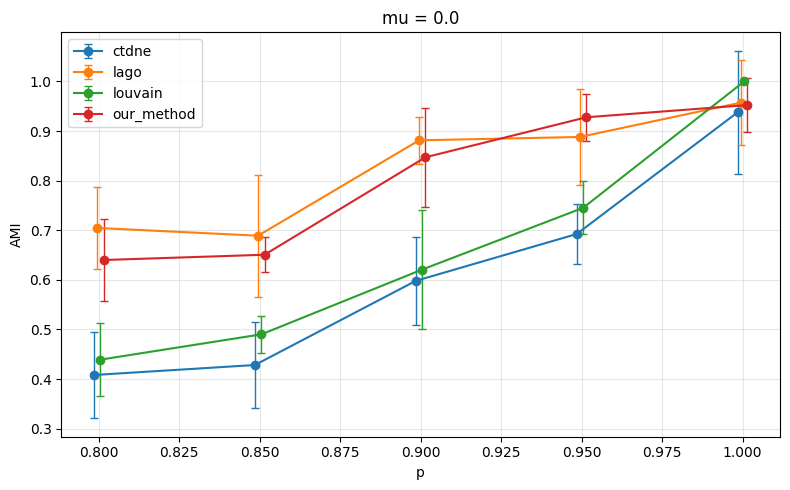

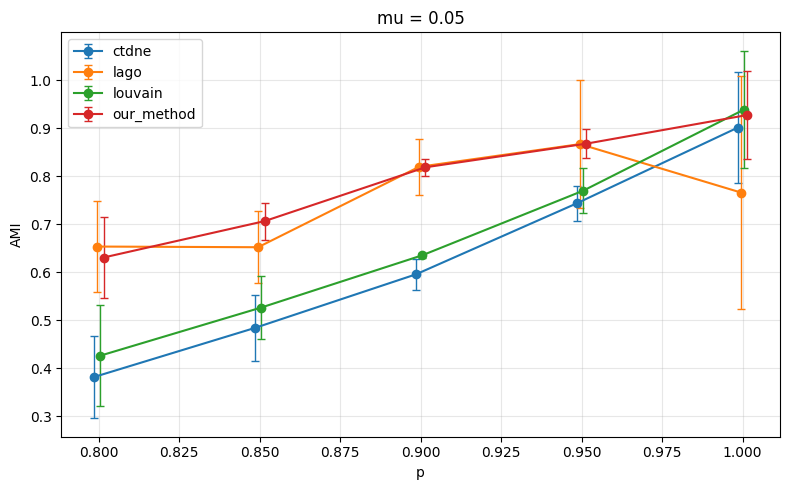

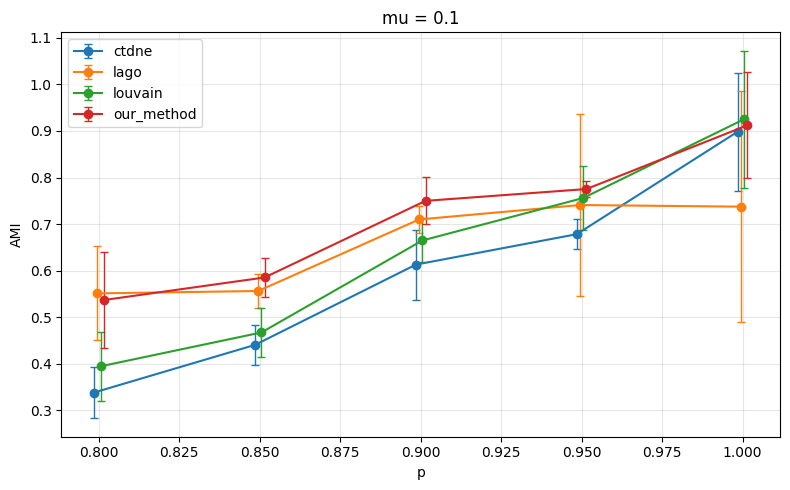

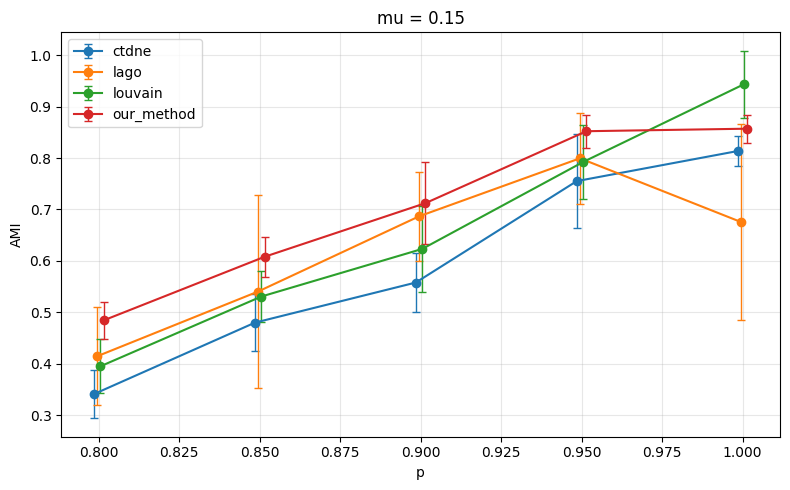

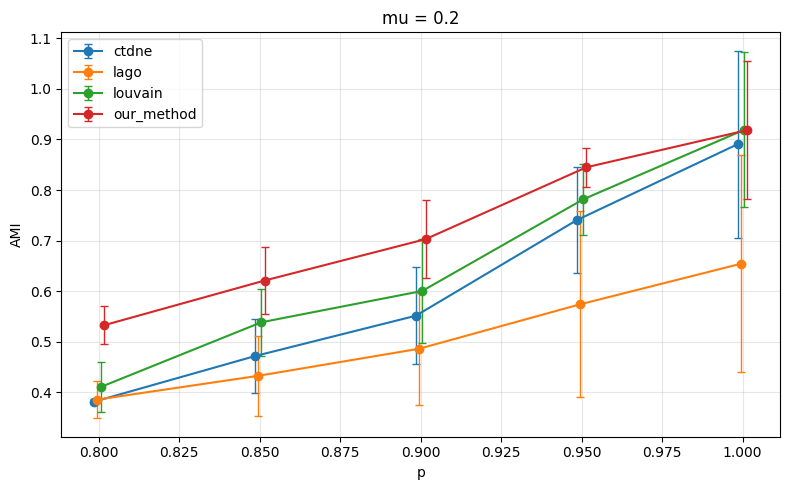

In [21]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "results"

pattern = r"p([0-9.]+)_mu([0-9.]+)_(\d+)"

all_grouped = []

csv_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.csv")))
print(f"Found {len(csv_files)} csv files.")

for file_path in csv_files:
    algo_name = os.path.splitext(os.path.basename(file_path))[0]
    print(f"Processing: {algo_name}")

    df = pd.read_csv(file_path)

    if "ami" in df.columns:
        score_col = "ami"
    else:
        print(f"Skip {algo_name}: no 'ami' or 'best_ami' column")
        continue

    if "data_name" not in df.columns:
        print(f"Skip {algo_name}: no 'data_name' column")
        continue

    df = df[["data_name", score_col]].copy()
    df = df.rename(columns={score_col: "ami"})

    parsed = df["data_name"].str.extract(pattern)
    parsed.columns = ["p", "mu", "index"]

    valid_mask = parsed.notna().all(axis=1)
    df = df.loc[valid_mask].copy()
    parsed = parsed.loc[valid_mask].copy()

    df["p"] = parsed["p"].astype(float)
    df["mu"] = parsed["mu"].astype(float)
    df["index"] = parsed["index"].astype(int)

    grouped = (
        df.groupby(["mu", "p"])["ami"]
          .agg(["mean", "std"])
          .reset_index()
    )
    grouped["algorithm"] = algo_name
    all_grouped.append(grouped)

if not all_grouped:
    raise ValueError("No valid CSV data found in results/")

all_grouped_df = pd.concat(all_grouped, ignore_index=True)

print(all_grouped_df.head())

mu_list = sorted(all_grouped_df["mu"].unique())
for mu in mu_list:
    plt.figure(figsize=(8, 5))

    sub_mu = all_grouped_df[all_grouped_df["mu"] == mu]
    algos = sorted(sub_mu["algorithm"].unique())

    n = len(algos)
    offsets = [(i - (n - 1) / 2) * 0.001 for i in range(n)]

    for i, algo in enumerate(algos):
        sub_algo = sub_mu[sub_mu["algorithm"] == algo].sort_values("p")

        x = sub_algo["p"].to_numpy() + offsets[i]
        y = sub_algo["mean"].to_numpy()
        e = sub_algo["std"].fillna(0).to_numpy()

        plt.errorbar(
            x,
            y,
            yerr=e,
            marker="o",
            capsize=3,
            elinewidth=1,
            linewidth=1.5,
            label=algo
        )

    plt.xlabel("p")
    plt.ylabel("AMI")
    plt.title(f"mu = {mu}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Found 4 csv files.
Processing: ctdne
Processing: lago
Processing: louvain
Processing: our_method

Aggregated results:
     algorithm    p   mu  layer      mean  count       std     error
0        ctdne  0.8  0.2      5  0.381721      4  0.004557  0.004557
1        ctdne  0.8  0.2     10  0.132586      4  0.007298  0.007298
2        ctdne  0.8  0.2     15  0.092090      4  0.007804  0.007804
3        ctdne  0.8  0.2     20  0.073695      4  0.002862  0.002862
4         lago  0.8  0.2      5  0.385880      4  0.037078  0.037078
5         lago  0.8  0.2     10  0.227777      4  0.013558  0.013558
6         lago  0.8  0.2     15  0.196362      4  0.013082  0.013082
7         lago  0.8  0.2     20  0.210578      4  0.029533  0.029533
8      louvain  0.8  0.2      5  0.428175      4  0.035121  0.035121
9      louvain  0.8  0.2     10  0.206725      4  0.017001  0.017001
10     louvain  0.8  0.2     15  0.128683      4  0.013997  0.013997
11     louvain  0.8  0.2     20  0.068268      4  0.01

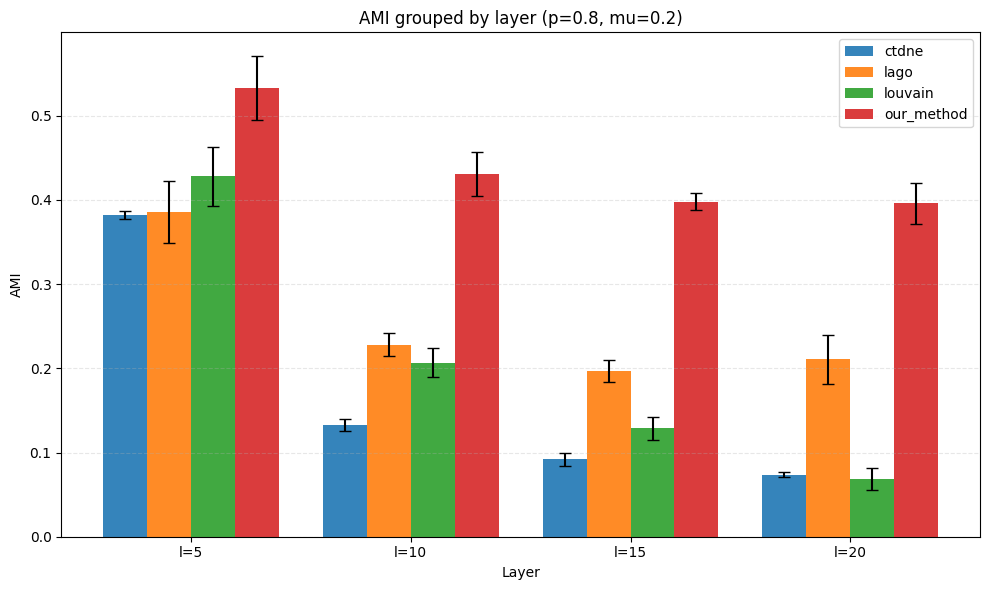

Saved figure to: ami_bar_p0.8_mu0.2.png


In [13]:
import os
import re
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= 配置 =========
INPUT_DIR = "results/layer"
OUTPUT_DIR = ""
#os.makedirs(OUTPUT_DIR, exist_ok=True)

# errorbar 类型：
# "std"  -> 标准差
# "sem"  -> 标准误 = std / sqrt(n)
ERROR_TYPE = "std"

# 是否在柱子上显示数值
SHOW_VALUE = False

# data_name 示例: p0.8_mu0.2_l5_1.csv
PATTERN = re.compile(
    r"p(?P<p>[0-9.]+)_mu(?P<mu>[0-9.]+)_l(?P<layer>\d+)_(?P<idx>\d+)(?:\.csv)?$"
)


def compute_error(x, error_type="std"):
    """根据一组数值计算 errorbar。"""
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    std = np.std(x, ddof=1)
    if error_type == "std":
        return std
    elif error_type == "sem":
        return std / math.sqrt(len(x))
    else:
        raise ValueError(f"Unsupported ERROR_TYPE: {error_type}")


# ========= 读取所有算法结果 =========
all_dfs = []

csv_files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.csv")))
if not csv_files:
    raise FileNotFoundError(f"No csv files found in {INPUT_DIR}")

print(f"Found {len(csv_files)} csv files.")

for file_path in csv_files:
    algo_name = os.path.splitext(os.path.basename(file_path))[0]
    print(f"Processing: {algo_name}")

    df = pd.read_csv(file_path)

    # 兼容 ami / best_ami
    if "ami" in df.columns:
        score_col = "ami"
    elif "best_ami" in df.columns:
        score_col = "best_ami"
    else:
        print(f"Skip {algo_name}: no 'ami' or 'best_ami' column")
        continue

    if "data_name" not in df.columns:
        print(f"Skip {algo_name}: no 'data_name' column")
        continue

    tmp = df[["data_name", score_col]].copy()
    tmp = tmp.rename(columns={score_col: "ami"})
    tmp["algorithm"] = algo_name

    parsed = tmp["data_name"].astype(str).str.extract(PATTERN)
    valid_mask = parsed.notna().all(axis=1)

    if valid_mask.sum() == 0:
        print(f"Skip {algo_name}: no valid data_name matched pattern")
        continue

    tmp = tmp.loc[valid_mask].copy()
    parsed = parsed.loc[valid_mask].copy()

    tmp["p"] = parsed["p"].astype(float)
    tmp["mu"] = parsed["mu"].astype(float)
    tmp["layer"] = parsed["layer"].astype(int)
    tmp["idx"] = parsed["idx"].astype(int)

    all_dfs.append(tmp)

if not all_dfs:
    raise ValueError("No valid data loaded.")

full_df = pd.concat(all_dfs, ignore_index=True)

# ========= 按 (algorithm, p, mu, layer) 聚合，idx 用来算 mean/error =========
grouped = (
    full_df.groupby(["algorithm", "p", "mu", "layer"])["ami"]
    .agg(
        mean="mean",
        count="count",
        std=lambda x: np.std(x, ddof=1) if len(x) > 1 else 0.0,
        error=lambda x: compute_error(x, ERROR_TYPE),
    )
    .reset_index()
)

print("\nAggregated results:")
print(grouped)

# ========= 对每个 (p, mu) 画一张图 =========
pm_pairs = (
    grouped[["p", "mu"]]
    .drop_duplicates()
    .sort_values(["mu", "p"])
    .itertuples(index=False, name=None)
)

for p_val, mu_val in pm_pairs:
    sub = grouped[(grouped["p"] == p_val) & (grouped["mu"] == mu_val)].copy()
    if sub.empty:
        continue

    algorithms = sorted(sub["algorithm"].unique())
    layers = sorted(sub["layer"].unique())

    x = np.arange(len(layers))
    n_algos = len(algorithms)
    bar_width = 0.8 / max(n_algos, 1)

    plt.figure(figsize=(10, 6))

    for i, algo in enumerate(algorithms):
        algo_sub = sub[sub["algorithm"] == algo].set_index("layer")

        means = [algo_sub.loc[layer, "mean"] if layer in algo_sub.index else np.nan for layer in layers]
        errors = [algo_sub.loc[layer, "error"] if layer in algo_sub.index else 0.0 for layer in layers]

        positions = x - 0.4 + bar_width / 2 + i * bar_width

        bars = plt.bar(
            positions,
            means,
            width=bar_width,
            yerr=errors,
            capsize=4,
            label=algo,
            alpha=0.9,
        )

        if SHOW_VALUE:
            for bar, val in zip(bars, means):
                if not np.isnan(val):
                    plt.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height(),
                        f"{val:.3f}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                    )

    plt.xticks(x, [f"l={layer}" for layer in layers])
    plt.xlabel("Layer")
    plt.ylabel("AMI")
    plt.title(f"AMI grouped by layer (p={p_val}, mu={mu_val})")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, f"ami_bar_p{p_val}_mu{mu_val}.png")
    #plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved figure to: {save_path}")